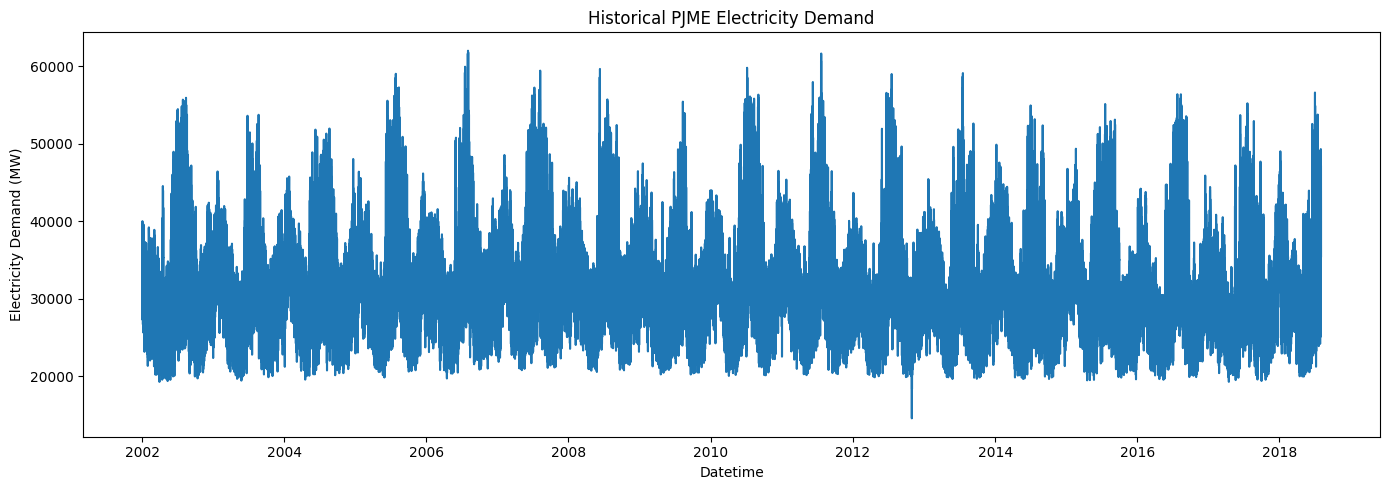

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("PJME_hourly.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["PJME_MW"])
plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.title("Historical PJME Electricity Demand")
plt.tight_layout()
plt.show()

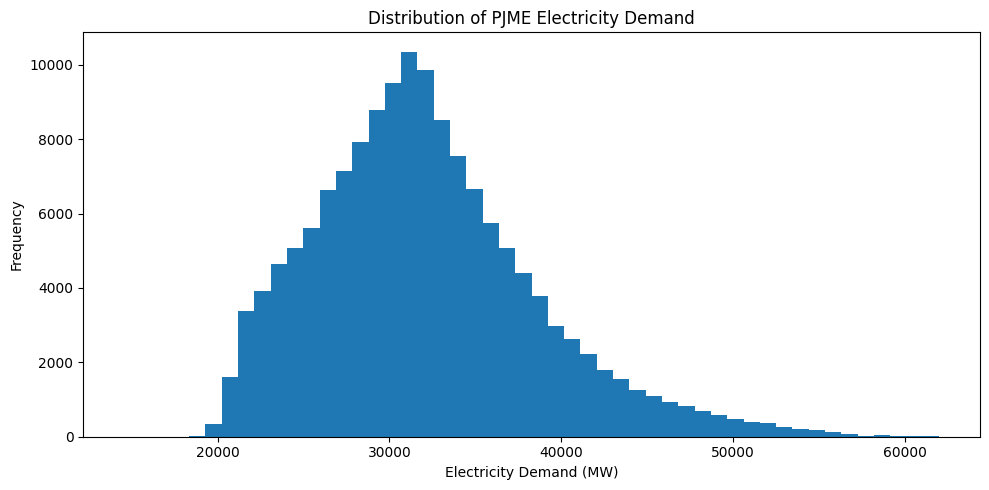

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df["PJME_MW"], bins=50)
plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Frequency")
plt.title("Distribution of PJME Electricity Demand")
plt.tight_layout()
plt.show()

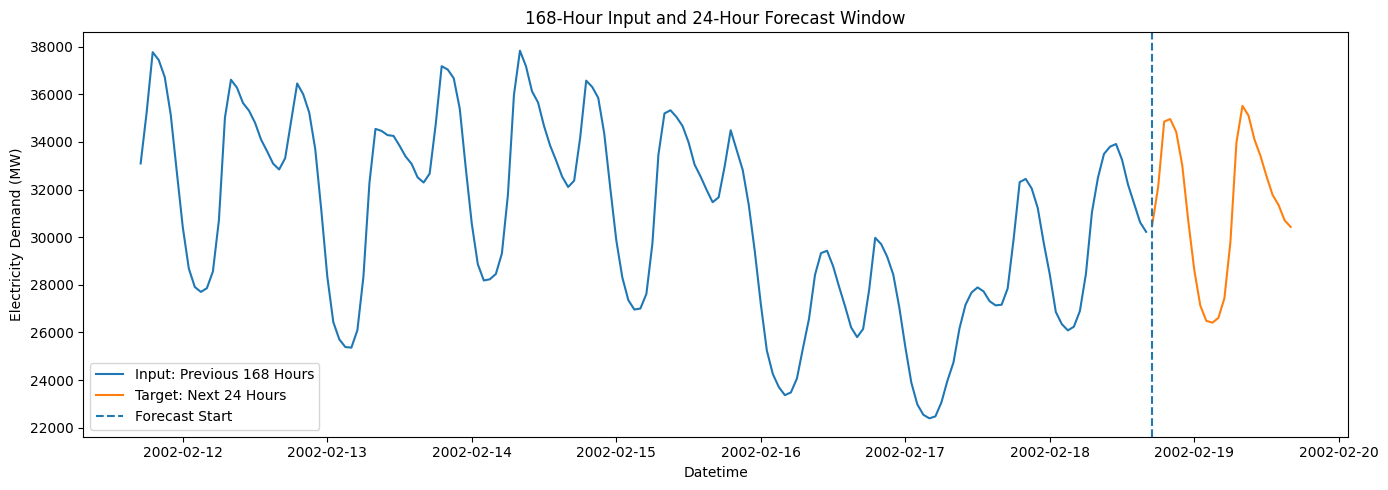

In [3]:
import matplotlib.pyplot as plt

# Select one forecasting sample
sample_start = 1000

input_data = df.iloc[sample_start:sample_start + 168]
target_data = df.iloc[sample_start + 168:sample_start + 192]

plt.figure(figsize=(14, 5))

plt.plot(
    input_data["Datetime"],
    input_data["PJME_MW"],
    label="Input: Previous 168 Hours"
)

plt.plot(
    target_data["Datetime"],
    target_data["PJME_MW"],
    label="Target: Next 24 Hours"
)

plt.axvline(
    x=target_data["Datetime"].iloc[0],
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.title("168-Hour Input and 24-Hour Forecast Window")
plt.legend()
plt.tight_layout()
plt.show()

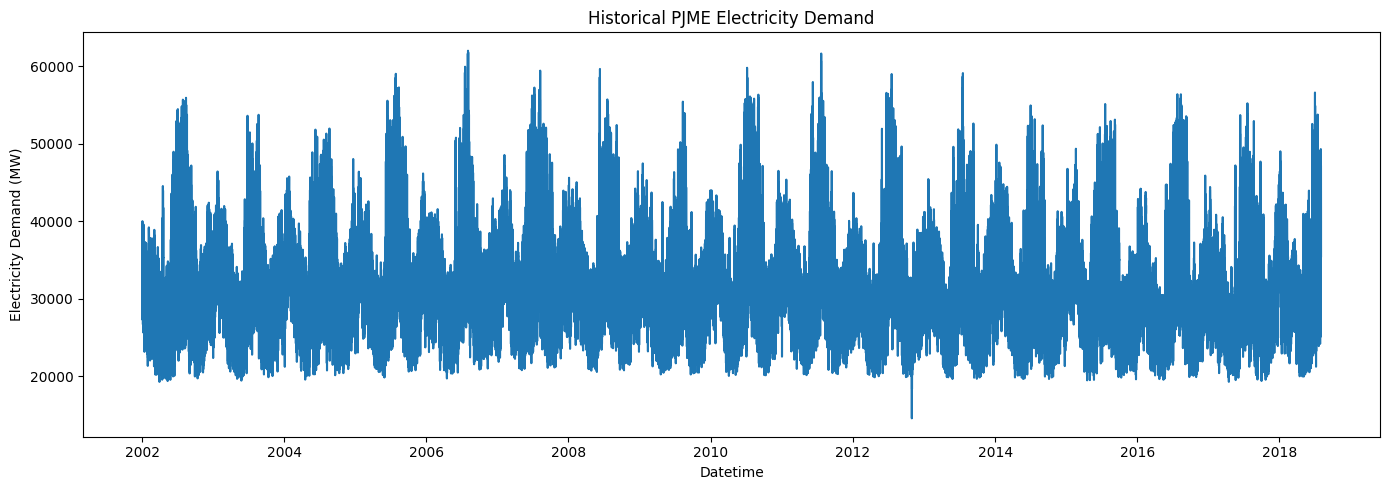

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("PJME_hourly.csv")
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")

plt.figure(figsize=(14, 5))
plt.plot(df["Datetime"], df["PJME_MW"])
plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.title("Historical PJME Electricity Demand")
plt.tight_layout()

plt.savefig("Figure_3_1_Historical_PJME_Demand.png", dpi=300, bbox_inches="tight")
plt.show()

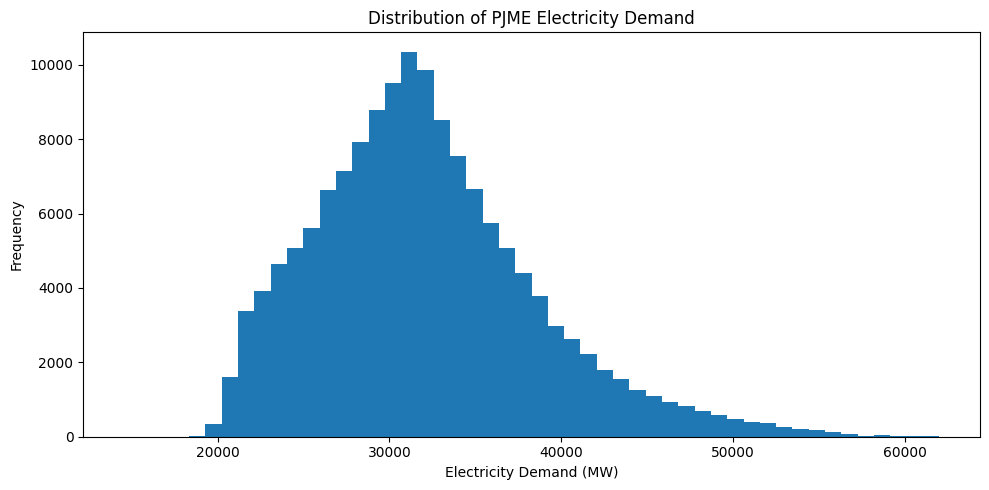

In [5]:
plt.figure(figsize=(10, 5))
plt.hist(df["PJME_MW"], bins=50)
plt.xlabel("Electricity Demand (MW)")
plt.ylabel("Frequency")
plt.title("Distribution of PJME Electricity Demand")
plt.tight_layout()

plt.savefig("Figure_3_2_PJME_Demand_Distribution.png", dpi=300, bbox_inches="tight")
plt.show()

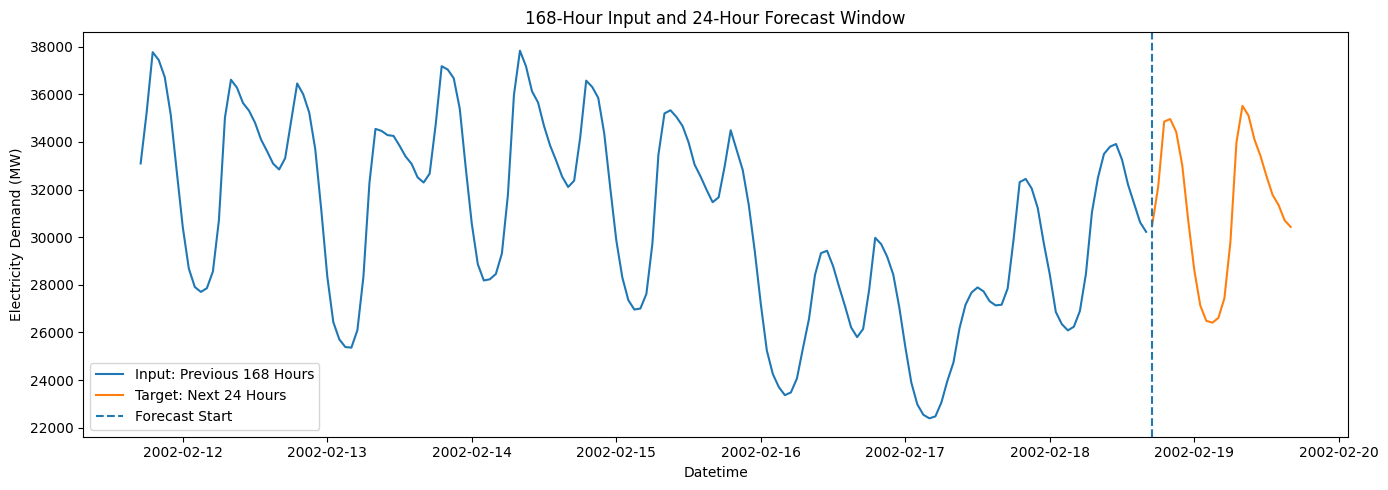

In [6]:
sample_start = 1000

input_data = df.iloc[sample_start:sample_start + 168]
target_data = df.iloc[sample_start + 168:sample_start + 192]

plt.figure(figsize=(14, 5))

plt.plot(
    input_data["Datetime"],
    input_data["PJME_MW"],
    label="Input: Previous 168 Hours"
)

plt.plot(
    target_data["Datetime"],
    target_data["PJME_MW"],
    label="Target: Next 24 Hours"
)

plt.axvline(
    x=target_data["Datetime"].iloc[0],
    linestyle="--",
    label="Forecast Start"
)

plt.xlabel("Datetime")
plt.ylabel("Electricity Demand (MW)")
plt.title("168-Hour Input and 24-Hour Forecast Window")
plt.legend()
plt.tight_layout()

plt.savefig("Figure_3_3_168_Hour_Input_24_Hour_Forecast.png",
            dpi=300, bbox_inches="tight")
plt.show()

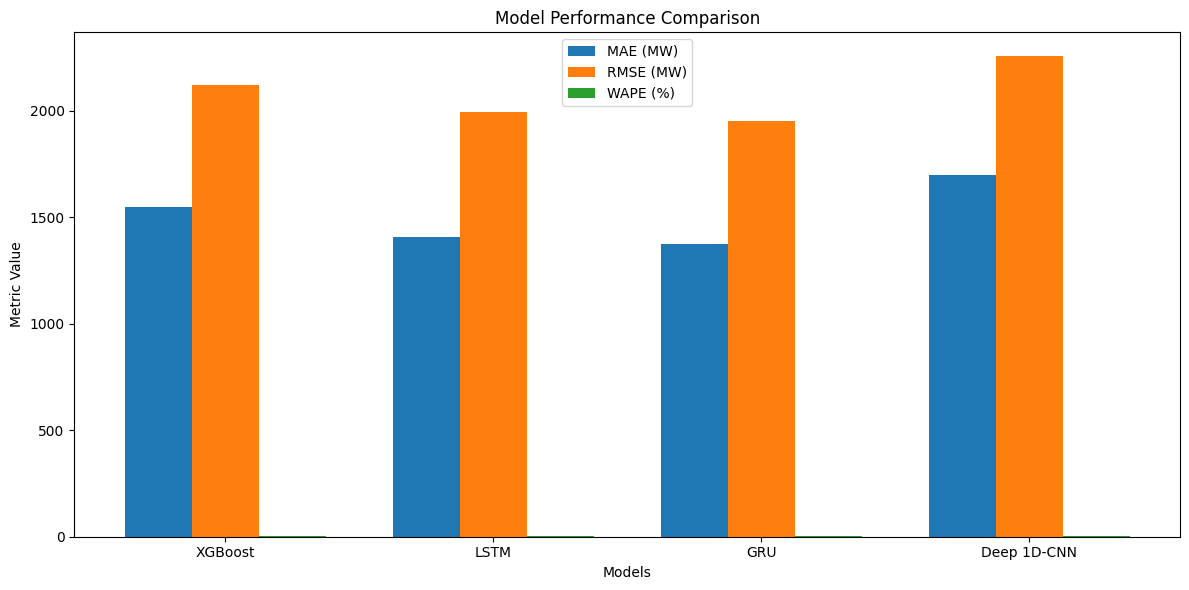

In [7]:
import matplotlib.pyplot as plt
import numpy as np

models = ["XGBoost", "LSTM", "GRU", "Deep 1D-CNN"]

mae = [1549.01, 1408.33, 1373.72, 1696.57]
rmse = [2123.68, 1992.24, 1954.52, 2255.89]
wape = [4.98, 4.53, 4.42, 5.46]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(x - width, mae, width, label="MAE (MW)")
plt.bar(x, rmse, width, label="RMSE (MW)")
plt.bar(x + width, wape, width, label="WAPE (%)")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Metric Value")
plt.title("Model Performance Comparison")
plt.legend()

plt.tight_layout()

plt.savefig(
    "Figure_5_1_Model_Comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()